# **NBA Player Salary Analysis and Prediction**

This project analyzes and predicts NBA player salaries based on physical attributes and categorical features. It uses **data visualization**, **correlation analysis**, **clustering**, and **linear regression modeling**.


---



# **Loading the dataset**

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("nba.csv")
df

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8.0,PF,29.0,6-10,231.0,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8.0,PG,26.0,6-3,203.0,Butler,2433333.0
454,Raul Neto,Utah Jazz,25.0,PG,24.0,6-1,179.0,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21.0,C,26.0,7-3,256.0,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24.0,C,26.0,7-0,231.0,Kansas,947276.0


# **Some initial enquiry to understand the dataframe**

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      457 non-null    object 
 1   Team      457 non-null    object 
 2   Number    457 non-null    float64
 3   Position  457 non-null    object 
 4   Age       457 non-null    float64
 5   Height    457 non-null    object 
 6   Weight    457 non-null    float64
 7   College   373 non-null    object 
 8   Salary    446 non-null    float64
dtypes: float64(4), object(5)
memory usage: 32.3+ KB


In [57]:
df.describe()

,Number,Age,Weight,Salary
count,457.000000,457.000000,457.000000,4.460000e+02
mean,17.678337,26.938731,221.522976,4.842684e+06
std,15.966090,4.404016,26.368343,5.229238e+06
min,0.000000,19.000000,161.000000,3.088800e+04
25%,5.000000,24.000000,200.000000,1.044792e+06
50%,13.000000,26.000000,220.000000,2.839073e+06
75%,25.000000,30.000000,240.000000,6.500000e+06
max,99.000000,40.000000,307.000000,2.500000e+07


In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
df.isnull().sum()

Name         1
Team         1
Number       1
Position     1
Age          1
Height       1
Weight       1
College     85
Salary      12
dtype: int64

In [60]:
df[df["Team"]=="Boston Celtics"][["Name","Age"]].head()

,Name,Age
0,Avery Bradley,25.0
1,Jae Crowder,25.0
2,John Holland,27.0
3,R.J. Hunter,22.0
4,Jonas Jerebko,29.0


# **DATA MUNGING**

---



### **Handling NAN values**

In [61]:
df = df.dropna(subset=["Name"]).reset_index(drop=True)
df["College"]= df["College"].fillna("Unknown")
df["Salary"]= df["Salary"].fillna(df["Salary"].mean())
df.isnull().sum()

Name        0
Team        0
Number      0
Position    0
Age         0
Height      0
Weight      0
College     0
Salary      0
dtype: int64

## **Here Height is not in numeric form. we will have to convert it.**

In [62]:
def convert(h):
    if isinstance(h, str) and '-' in h:
        feet, inches = h.split('-')
        return int(feet) + int(inches) / 12
    return None

df["Height (in feet)"] = df["Height"].apply(convert)

df.head(3)

,Name,Team,Number,Position,Age,Height,Weight,College,Salary,Height (in feet)
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7.730337e+06,6.166667
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6.796117e+06,6.500000
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,4.842684e+06,6.416667


# **THE DATA IS CLEANED**

---



In [63]:
df.head(10)

,Name,Team,Number,Position,Age,Height,Weight,College,Salary,Height (in feet)
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7.730337e+06,6.166667
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6.796117e+06,6.500000
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,4.842684e+06,6.416667
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1.148640e+06,6.416667
4,Jonas Jerebko,Boston Celtics,8.0,PF,29.0,6-10,231.0,Unknown,5.000000e+06,6.833333
5,Amir Johnson,Boston Celtics,90.0,PF,29.0,6-9,240.0,Unknown,1.200000e+07,6.750000
6,Jordan Mickey,Boston Celtics,55.0,PF,21.0,6-8,235.0,LSU,1.170960e+06,6.666667
7,Kelly Olynyk,Boston Celtics,41.0,C,25.0,7-0,238.0,Gonzaga,2.165160e+06,7.000000
8,Terry Rozier,Boston Celtics,12.0,PG,22.0,6-2,190.0,Louisville,1.824360e+06,6.166667
9,Marcus Smart,Boston Celtics,36.0,PG,22.0,6-4,220.0,Oklahoma State,3.431040e+06,6.333333




---



# **EXPLORATORY DATA ANALYSIS**

## *General Overview*

### **1.How many unique players are there?**

In [64]:
a=sorted(df["Name"].dropna().unique())
print(f"there are {len(a)} unique players in NBA \n", pd.DataFrame(a))

there are 457 unique players in NBA 
                    0
0       Aaron Brooks
1       Aaron Gordon
2     Aaron Harrison
3      Adreian Payne
4         Al Horford
..               ...
452  Wilson Chandler
453   Xavier Munford
454      Zach LaVine
455    Zach Randolph
456    Zaza Pachulia

[457 rows x 1 columns]


### **2. How many teams are represented in the dataset?**

In [65]:
b=sorted(df["Team"].dropna().unique())
print(f"there are {len(b)} teams in the league\n", pd.DataFrame(b,columns=["TEAMS"]))

there are 30 teams in the league
                      TEAMS
0            Atlanta Hawks
1           Boston Celtics
2            Brooklyn Nets
3        Charlotte Hornets
4            Chicago Bulls
5      Cleveland Cavaliers
6         Dallas Mavericks
7           Denver Nuggets
8          Detroit Pistons
9    Golden State Warriors
10         Houston Rockets
11          Indiana Pacers
12    Los Angeles Clippers
13      Los Angeles Lakers
14       Memphis Grizzlies
15              Miami Heat
16         Milwaukee Bucks
17  Minnesota Timberwolves
18    New Orleans Pelicans
19         New York Knicks
20   Oklahoma City Thunder
21           Orlando Magic
22      Philadelphia 76ers
23            Phoenix Suns
24  Portland Trail Blazers
25        Sacramento Kings
26       San Antonio Spurs
27         Toronto Raptors
28               Utah Jazz
29      Washington Wizards


### **3. What positions are present, and how many players are in each position?**

In [66]:
c=df["Position"].unique()
print(f"there are {len(c)} positions \n", pd.DataFrame(c,columns=["POSITIONS"]))

there are 5 positions 
   POSITIONS
0        PG
1        SF
2        SG
3        PF
4         C


In [67]:
df["Position"].value_counts()

Position
SG    102
PF    100
PG     92
SF     85
C      78
Name: count, dtype: int64

# ***Salary Analysis***

### **4. What is the average salary of players overall?**

In [68]:
print(f"the average salay is {df['Salary'].mean()}")

the average salay is 4842684.105381167


### **5.Which players have the highest and lowest salaries?**

In [69]:
d=df[["Name","Salary"]]
print("the player with the highest salary\n",d.loc[d["Salary"].idxmax()])
print("\n the player with the lowest salary\n",d.loc[d["Salary"].idxmin()])

the player with the highest salary
 Name      Kobe Bryant
Salary     25000000.0
Name: 109, dtype: object

 the player with the lowest salary
 Name      Thanasis Antetokounmpo
Salary                   30888.0
Name: 32, dtype: object


### **6. What is the average salary by:**
### **Team?**
### **Position?**
### **Age group?**

In [70]:
t=df.groupby("Team")["Salary"].mean()
print("the average salary by team\n",t)

the average salary by team
 Team
Atlanta Hawks             4.860197e+06
Boston Celtics            4.225583e+06
Brooklyn Nets             3.501898e+06
Charlotte Hornets         5.222728e+06
Chicago Bulls             5.785559e+06
Cleveland Cavaliers       7.455425e+06
Dallas Mavericks          4.746582e+06
Denver Nuggets            4.330974e+06
Detroit Pistons           4.477884e+06
Golden State Warriors     5.924600e+06
Houston Rockets           5.018868e+06
Indiana Pacers            4.450122e+06
Los Angeles Clippers      6.323643e+06
Los Angeles Lakers        4.784695e+06
Memphis Grizzlies         5.328979e+06
Miami Heat                6.146736e+06
Milwaukee Bucks           4.350220e+06
Minnesota Timberwolves    4.610884e+06
New Orleans Pelicans      4.355304e+06
New York Knicks           4.581494e+06
Oklahoma City Thunder     6.251020e+06
Orlando Magic             4.297248e+06
Philadelphia 76ers        2.389039e+06
Phoenix Suns              4.229676e+06
Portland Trail Blazers    3.220

In [71]:
p=df.groupby("Position")["Salary"].mean()
print("the average salary by Position\n",p)

the average salary by Position
 Position
C     5.967052e+06
PF    4.570889e+06
PG    5.067606e+06
SF    4.857220e+06
SG    4.034356e+06
Name: Salary, dtype: float64


In [72]:
ag=df.groupby("Age")["Salary"].mean()
print("the average salary by age\n",ag)

the average salary by age
 Age
19.0    1.930440e+06
20.0    2.725791e+06
21.0    2.067380e+06
22.0    2.357963e+06
23.0    2.171719e+06
24.0    3.830295e+06
25.0    3.951130e+06
26.0    6.866566e+06
27.0    6.632008e+06
28.0    5.101559e+06
29.0    6.174838e+06
30.0    6.990272e+06
31.0    8.511397e+06
32.0    7.716958e+06
33.0    3.930739e+06
34.0    7.606030e+06
35.0    3.615178e+06
36.0    2.238120e+06
37.0    1.079400e+07
38.0    1.840041e+06
39.0    2.517872e+06
40.0    4.666917e+06
Name: Salary, dtype: float64


### ***7. Total players in each team***

In [73]:
grouped=df.groupby("Team")
for team, group in grouped:
    print(f"\n🏀 {team}")
    print(group.to_string(index=False))


🏀 Atlanta Hawks
            Name          Team  Number Position  Age Height  Weight        College     Salary  Height (in feet)
   Kent Bazemore Atlanta Hawks    24.0       SF 26.0    6-5   201.0   Old Dominion  2000000.0          6.416667
Tim Hardaway Jr. Atlanta Hawks    10.0       SG 24.0    6-6   205.0       Michigan  1304520.0          6.500000
    Kirk Hinrich Atlanta Hawks    12.0       SG 35.0    6-4   190.0         Kansas  2854940.0          6.333333
      Al Horford Atlanta Hawks    15.0        C 30.0   6-10   245.0        Florida 12000000.0          6.833333
  Kris Humphries Atlanta Hawks    43.0       PF 31.0    6-9   235.0      Minnesota  1000000.0          6.750000
     Kyle Korver Atlanta Hawks    26.0       SG 35.0    6-7   212.0      Creighton  5746479.0          6.583333
    Paul Millsap Atlanta Hawks     4.0       PF 31.0    6-8   246.0 Louisiana Tech 18671659.0          6.666667
    Mike Muscala Atlanta Hawks    31.0       PF 24.0   6-11   240.0       Bucknell   94

# ***Position-Based Analysis***

### **8. What is the average age, height, and weight of players by position?**

In [74]:
pos=df.groupby("Position")[["Age","Height (in feet)","Weight"]].mean()
print(pos)


                Age  Height (in feet)      Weight
Position                                         
C         27.371795          6.941239  254.205128
PF        27.160000          6.809167  240.430000
PG        26.847826          6.202899  189.478261
SF        26.858824          6.632353  221.776471
SG        26.539216          6.461601  206.686275


### **9. Which position has the highest average salary?**

In [75]:
df.groupby("Position")["Salary"].mean().sort_values(ascending=False).head(1)

Position
C    5967052.0
Name: Salary, dtype: float64

### **10. Do taller players tend to earn more?**

In [76]:
tol=df[["Height (in feet)","Salary"]]
tol.sort_values(by="Height (in feet)",ascending=False).head(10)

,Height (in feet),Salary
455,7.250000,2900000.0
322,7.250000,1000000.0
40,7.250000,4131720.0
302,7.250000,1200000.0
275,7.166667,4389607.0
235,7.166667,525093.0
111,7.166667,15592217.0
265,7.083333,19688000.0
128,7.083333,3807120.0
329,7.083333,6110034.0


In [77]:
correlation = df["Height (in feet)"].corr(df["Salary"])
print(f"Correlation between height and salary: {correlation:.3f}")


Correlation between height and salary: 0.058


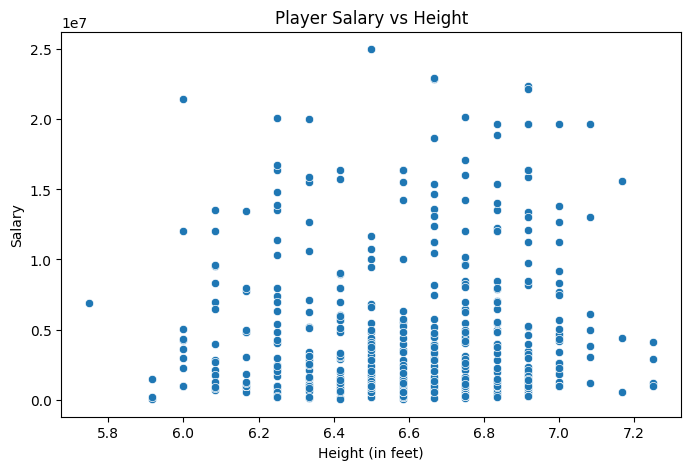

In [78]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Height (in feet)", y="Salary")
plt.title("Player Salary vs Height")
plt.xlabel("Height (in feet)")
plt.ylabel("Salary")
plt.show()

## ***A correlation of 0.058 means there's almost no linear relationship between player height and salary in your dataset.***

---





# ***College Insights***

### **11. How many players came from each college?**

In [79]:
df.groupby("College")["Name"].count().sort_values(ascending=False).head(10)

College
Unknown           84
Kentucky          22
Duke              20
Kansas            18
North Carolina    16
UCLA              15
Arizona           13
Florida           10
Texas              9
Syracuse           8
Name: Name, dtype: int64

### **12. Which college produced the highest-paid player(s)?**

In [80]:
df[["College","Name","Salary"]].sort_values(by="Salary",ascending=False).head(10)

,College,Name,Salary
109,Unknown,Kobe Bryant,25000000.0
169,Unknown,LeBron James,22970500.0
33,Syracuse,Carmelo Anthony,22875000.0
251,Unknown,Dwight Howard,22359364.0
339,Georgia Tech,Chris Bosh,22192730.0
100,Wake Forest,Chris Paul,21468695.0
414,Texas,Kevin Durant,20158622.0
164,Memphis,Derrick Rose,20093064.0
349,Marquette,Dwyane Wade,20000000.0
294,Texas,LaMarcus Aldridge,19689000.0


In [81]:
df.groupby("College")["Salary"].max().sort_values(ascending=False).head(10)

College
Unknown         25000000.0
Syracuse        22875000.0
Georgia Tech    22192730.0
Wake Forest     21468695.0
Texas           20158622.0
Memphis         20093064.0
Marquette       20000000.0
UCLA            19689000.0
Stanford        19689000.0
Texas A&M       19689000.0
Name: Salary, dtype: float64

### **13. Are players with a college background paid more on average than those without?**

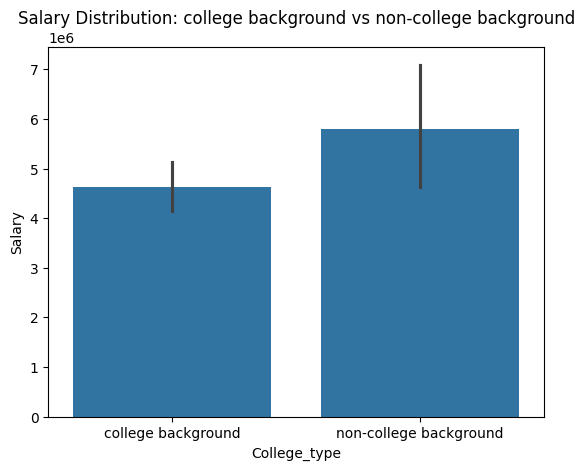

In [82]:
df["College_type"] = df["College"].apply(lambda x: "non-college background" if x == "Unknown" else "college background")

sns.barplot(data=df, x="College_type", y="Salary")
plt.title("Salary Distribution: college background vs non-college background")
plt.show()

# ***Age Distribution***

### **14. What is the average age of players?**

In [83]:
print("the average age of players is", df["Age"].mean())

the average age of players is 26.938730853391686


### **16. Is there any correlation between age and salary?**

In [84]:
correlationn= df["Age"].corr(df["Salary"])
print(f"Correlation between age and salary: {correlationn:.3f}")

Correlation between age and salary: 0.211


## As age increases, salary tends to increase slightly.

### But the relationship is not strong — there are many exceptions.

# ***Height & Weight Insights***

### **17. What is the average height and weight of players?**

In [85]:
df.describe()[["Height (in feet)","Weight"]]

,Height (in feet),Weight
count,457.000000,457.000000
mean,6.599198,221.522976
std,0.286037,26.368343
min,5.750000,161.000000
25%,6.416667,200.000000
50%,6.666667,220.000000
75%,6.833333,240.000000
max,7.250000,307.000000


### **18. Which positions tend to be tallest or heaviest?**

In [86]:
pas=df[["Position","Height (in feet)"]]
pas.sort_values(by="Height (in feet)",ascending=False).head(10)

,Position,Height (in feet)
455,C,7.250000
322,C,7.250000
40,PF,7.250000
302,C,7.250000
275,C,7.166667
235,C,7.166667
111,C,7.166667
265,C,7.083333
128,C,7.083333
329,PF,7.083333


In [87]:
pas=df[["Position","Weight"]]
pas.sort_values(by="Weight",ascending=False).head(10)

,Position,Weight
405,C,307.0
302,C,290.0
330,C,289.0
395,C,280.0
188,C,279.0
41,C,278.0
155,PF,275.0
56,C,275.0
237,C,275.0
176,C,275.0


### ***C position seems to be both heaviest and tallest***

---



### **19. Is there a correlation between height/weight and salary?**

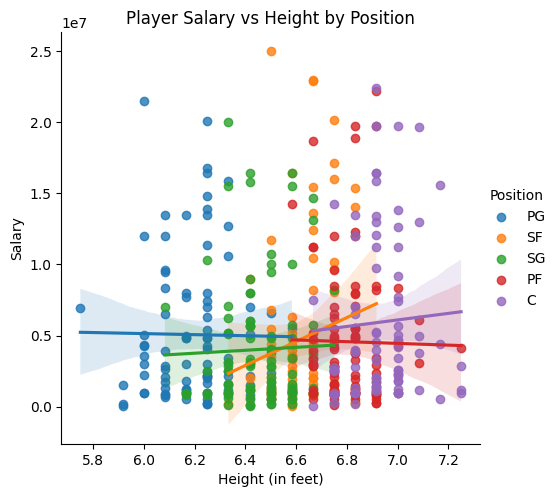

In [88]:
sns.lmplot(data=df, x="Height (in feet)", y="Salary", hue="Position", scatter=True)

plt.title("Player Salary vs Height by Position")
plt.xlabel("Height (in feet)")
plt.ylabel("Salary")
plt.show()


In [89]:
cor=df["Height (in feet)"].corr(df["Salary"])
print(f"Correlation between height and salary: {cor:.3f}")
cor=df["Weight"].corr(df["Salary"])
print(f"Correlation between Weight and salary: {cor:.3f}")

Correlation between height and salary: 0.058
Correlation between Weight and salary: 0.136


### Height (0.058):

Being taller doesn't seem to significantly affect salary.

There's **no clear trend** between player height and earnings.

### Weight (0.136):

Heavier players slightly tend to earn more.

But still **very weak** — other factors (position, skill, fame) matter much more.

---



# ***Advanced Explorations***

---



In [99]:
!pip install plotly 
!pip install scikit-learn 
!pip install ipywidgets

### **20. Create a heatmap of correlations (age, height, weight, salary).**

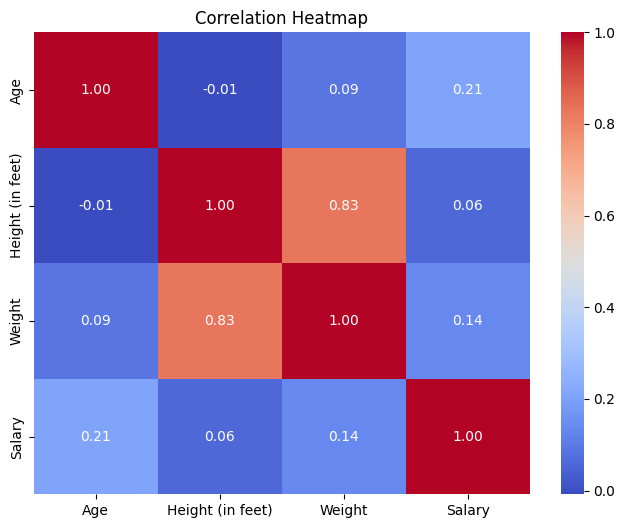

In [90]:
corl = df[['Age', 'Height (in feet)', 'Weight', 'Salary']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corl, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Salary shows no strong correlation with Age, Height, or Weight. This suggests that factors like Position, Experience, Performance, or Market value might play a larger role in determining salary, not just physical attributes.

### **21. Cluster players by physical attributes (height, weight) or salary.**

In [95]:
!pip install plotly ipywidgets --quiet

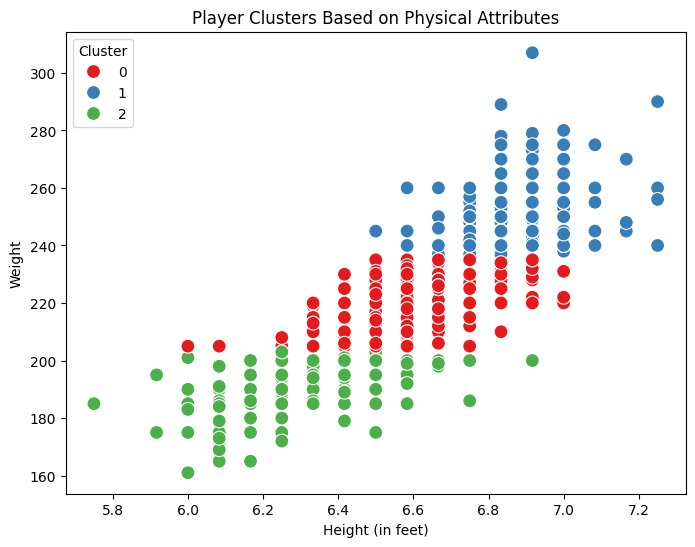

In [91]:
from sklearn.cluster import KMeans

X = df[['Height (in feet)', 'Weight']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Height (in feet)', y='Weight', hue='Cluster', palette='Set1', s=100)
plt.title("Player Clusters Based on Physical Attributes")
plt.xlabel("Height (in feet)")
plt.ylabel("Weight")
plt.legend(title="Cluster")
plt.show()

 Utilize the scatter plot to guide player role assignments by categorizing athletes into three groups—light builds (160-200 lbs, 5.8-6.4 ft) for agility-based roles, moderate builds (180-260 lbs, 5.8-6.6 ft) for versatile positions, and heavy builds (240-300 lbs, 6.4-7.2 ft) for strength-based roles—while initiating further data collection (e.g., position or performance stats) to resolve the overlap around 6.4 ft and 240 lbs and refine the clustering for optimal team strategy.

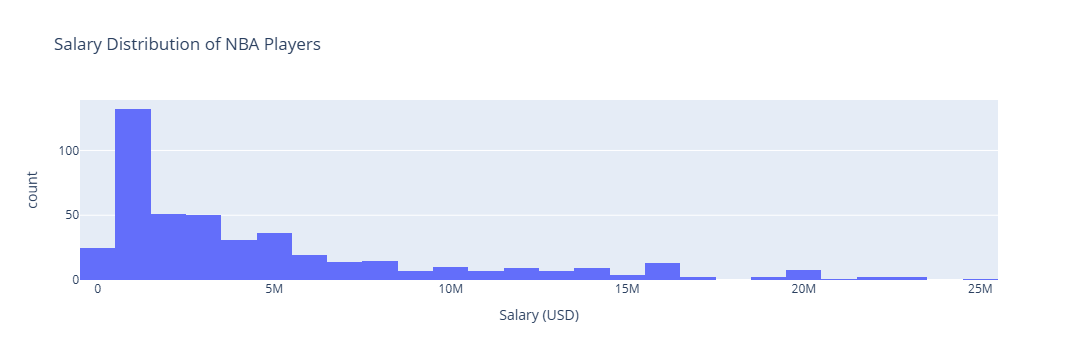

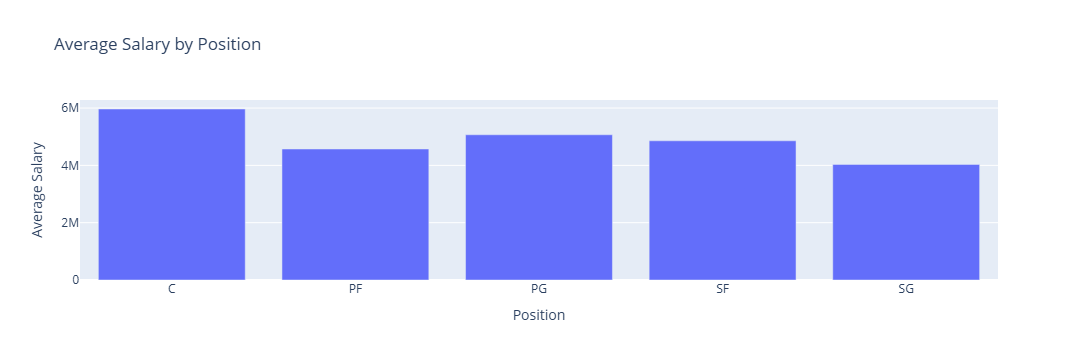

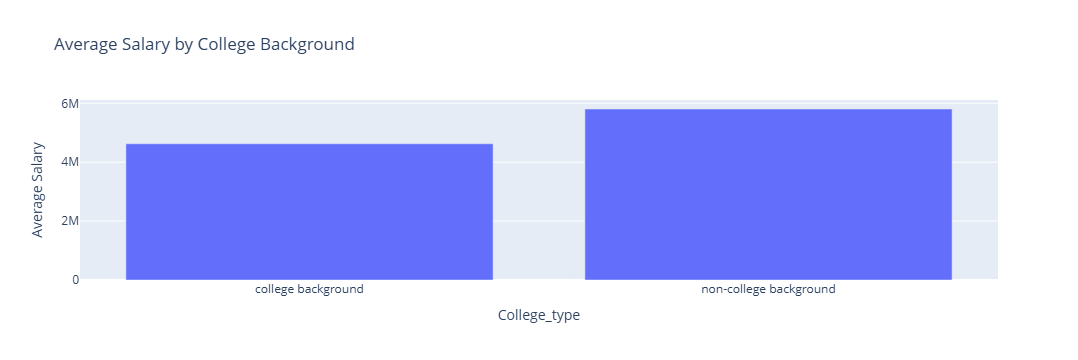

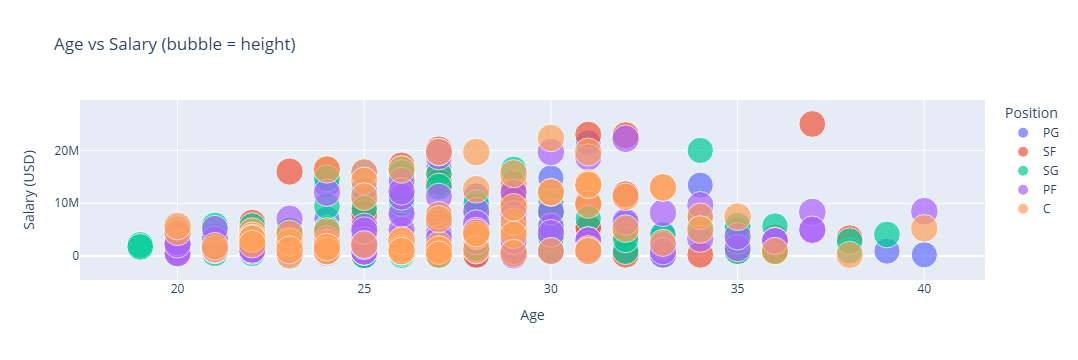

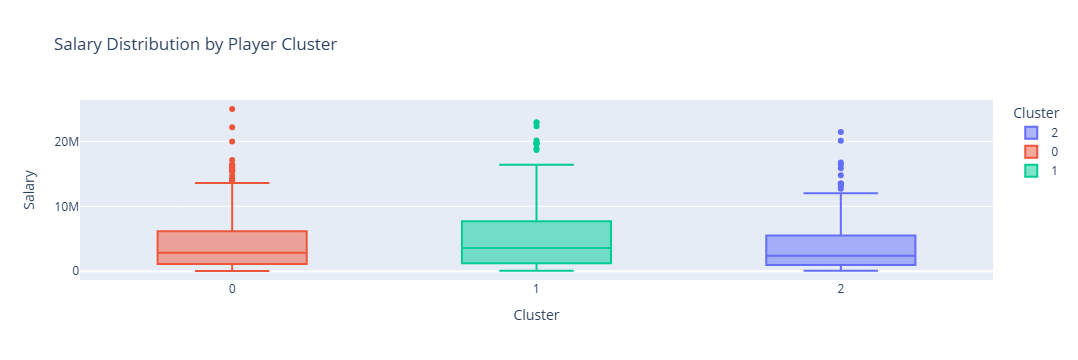

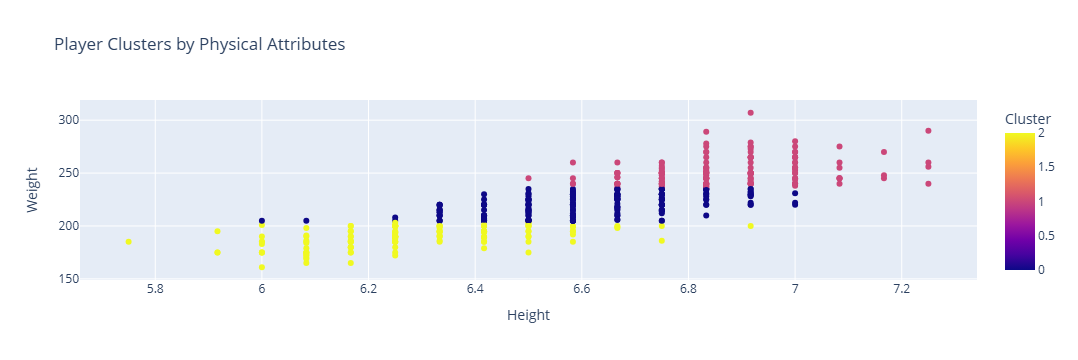

In [96]:
import plotly.express as px
import pandas as pd

# 1. Salary Distribution
fig1 = px.histogram(df, x='Salary', nbins=30,
                    title='Salary Distribution of NBA Players',
                    labels={'Salary': 'Salary (USD)'})
fig1.show()

# 2. Average Salary by Position
avg_salary_position = df.groupby('Position')['Salary'].mean().reset_index()
fig2 = px.bar(avg_salary_position, x='Position', y='Salary',
              title='Average Salary by Position',
              labels={'Salary': 'Average Salary'})
fig2.show()

# 3. Average Salary by College Type
avg_salary_college = df.groupby('College_type')['Salary'].mean().reset_index()
fig3 = px.bar(avg_salary_college, x='College_type', y='Salary',
              title='Average Salary by College Background',
              labels={'Salary': 'Average Salary'})
fig3.show()

# 4. Salary vs Age (Scatter)
fig4 = px.scatter(df, x='Age', y='Salary', color='Position',
                  size='Height (in feet)', hover_name='Name',
                  title='Age vs Salary (bubble = height)',
                  labels={'Salary': 'Salary (USD)'})
fig4.show()

# 5. Salary by Cluster (from KMeans)
fig5 = px.box(df, x='Cluster', y='Salary', color='Cluster',
              title='Salary Distribution by Player Cluster')
fig5.show()

# 6. Height vs Weight (colored by cluster)
fig6 = px.scatter(df, x='Height (in feet)', y='Weight', color='Cluster',
                  title='Player Clusters by Physical Attributes',
                  labels={'Height (in feet)': 'Height', 'Weight': 'Weight'})
fig6.show()


In [110]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output

# Clustering
from sklearn.cluster import KMeans
X = df[['Age', 'Height (in feet)', 'Weight', 'Salary']].dropna()
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = -1
df.loc[X.index, 'Cluster'] = kmeans.fit_predict(X)

# Widgets
position_dropdown = widgets.Dropdown(
    options=['All'] + sorted(df['Position'].dropna().unique().tolist()),
    value='All',
    description='Position:'
)

age_slider = widgets.IntRangeSlider(
    value=[int(df['Age'].min()), int(df['Age'].max())],
    min=int(df['Age'].min()),
    max=int(df['Age'].max()),
    step=1,
    description='Age Range:'
)

output = widgets.Output()

# Filter function
def filter_df(position, age_range):
    filtered = df.copy()
    if position != 'All':
        filtered = filtered[filtered['Position'] == position]
    filtered = filtered[(filtered['Age'] >= age_range[0]) & (filtered['Age'] <= age_range[1])]
    return filtered

# Update plot function
def update_plots(change=None):
    with output:
        clear_output(wait=True)
        filtered = filter_df(position_dropdown.value, age_slider.value)
        
        fig = make_subplots(rows=2, cols=3, 
                            subplot_titles=('Salary Distribution', 'Avg Salary by Position', 
                                            'Avg Salary by College Type', 'Age vs Salary', 
                                            'Salary by Cluster', 'Height vs Weight'),
                            vertical_spacing=0.15, horizontal_spacing=0.1)

        # Consistent color palette
        base_colors = px.colors.qualitative.Set2

        # 1. Salary Distribution
        fig.add_trace(
            go.Histogram(
                x=filtered['Salary'], nbinsx=30, marker=dict(color=base_colors[0]),
                opacity=0.75
            ),
            row=1, col=1
        )

        # 2. Avg Salary by Position
        avg_salary_pos = filtered.groupby('Position')['Salary'].mean().reset_index()
        fig.add_trace(
            go.Bar(
                x=avg_salary_pos['Position'], y=avg_salary_pos['Salary'],
                marker_color=base_colors[1]
            ),
            row=1, col=2
        )

        # 3. Avg Salary by College Type
        avg_salary_col = filtered.groupby('College_type')['Salary'].mean().reset_index()
        fig.add_trace(
            go.Bar(
                x=avg_salary_col['College_type'], y=avg_salary_col['Salary'],
                marker_color=base_colors[2]
            ),
            row=1, col=3
        )

        # 4. Age vs Salary Scatter (bubble)
        pos_colors = {pos: base_colors[i % len(base_colors)] for i, pos in enumerate(df['Position'].dropna().unique())}
        bubble_colors = [pos_colors.get(pos, '#aaa') for pos in filtered['Position']]

        fig.add_trace(
            go.Scatter(
                x=filtered['Age'], y=filtered['Salary'], mode='markers',
                marker=dict(
                    size=filtered['Height (in feet)'] * 3,
                    color=bubble_colors,
                    opacity=0.6,
                    line=dict(width=1, color='white')
                ),
                text=filtered['Name'], hoverinfo='text+x+y'
            ),
            row=2, col=1
        )

        # 5. Salary by Cluster (Box)
        cluster_colors = {str(i): base_colors[i % len(base_colors)] for i in range(3)}
        for cluster in sorted(filtered['Cluster'].unique()):
            cluster_data = filtered[filtered['Cluster'] == cluster]
            fig.add_trace(
                go.Box(
                    y=cluster_data['Salary'],
                    name=f"Cluster {cluster}",
                    boxpoints='outliers',
                    jitter=0.4,
                    pointpos=-1.8,
                    marker=dict(color=cluster_colors[str(cluster)], opacity=0.7)
                ),
                row=2, col=2
            )

        # 6. Height vs Weight Scatter
        cluster_color_list = [cluster_colors.get(str(c), '#999') for c in filtered['Cluster'].astype(str)]
        fig.add_trace(
            go.Scatter(
                x=filtered['Height (in feet)'], y=filtered['Weight'], mode='markers',
                marker=dict(
                    color=cluster_color_list,
                    size=8,
                    opacity=0.7,
                    line=dict(width=0.5, color='black')
                ),
                text=filtered['Name'], hoverinfo='text+x+y'
            ),
            row=2, col=3
        )

        # Layout
        fig.update_layout(
            height=900, width=1300,
            title_text="NBA Players Analysis Dashboard",
            template='plotly_white',
            title_font=dict(size=24),
            margin=dict(t=70, l=40, r=40, b=40)
        )

        fig.update_annotations(font_size=14)
        fig.update_xaxes(showgrid=True, zeroline=False)
        fig.update_yaxes(showgrid=True, zeroline=False)

        fig.show()

# Link widgets
position_dropdown.observe(update_plots, names='value')
age_slider.observe(update_plots, names='value')

# Display UI
display(widgets.VBox([position_dropdown, age_slider, output]))
update_plots()


In [125]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans
import ipywidgets as widgets
from IPython.display import display, clear_output

# Load and preprocess data
df = pd.read_csv("nba.csv")
df = df.dropna(subset=["Name"]).reset_index(drop=True)
df["College"] = df["College"].fillna("Unknown")
df["Salary"] = df["Salary"].fillna(df["Salary"].mean())

def convert_height(h):
    if isinstance(h, str) and '-' in h:
        feet, inches = h.split('-')
        return int(feet) + int(inches) / 12
    return None

df["Height (in feet)"] = df["Height"].apply(convert_height)
df['College_type'] = df['College'].apply(lambda x: 'non-college background' if x == 'Unknown' else 'college background')

# Clustering
X = df[['Age', 'Height (in feet)', 'Weight', 'Salary']].dropna()
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = -1
df.loc[X.index, 'Cluster'] = kmeans.fit_predict(X)

# Widgets
position_dropdown = widgets.Dropdown(
    options=['All'] + sorted(df['Position'].dropna().unique().tolist()),
    value='All',
    description='Position:'
)

age_slider = widgets.IntRangeSlider(
    value=[int(df['Age'].min()), int(df['Age'].max())],
    min=int(df['Age'].min()),
    max=int(df['Age'].max()),
    step=1,
    description='Age Range:'
)

output = widgets.Output()

# Color maps
color_map_pos = {
    'PG': '#1E3A8A',  # Indigo-ish Blue
    'SG': '#EF4444',  # Tomato Red
    'SF': '#10B981',  # Emerald Green
    'PF': '#F59E0B',  # Amber/Gold
    'C':  '#8B5CF6'   # Violet
}

color_map_cluster = {
    '0': '#FFB347',  # Warm Yellow / Apricot
    '1': '#1E3A8A',  # Indigo-ish Blue (from last set)
    '2': '#10B981'   # Emerald Green
}


# Filter function
def filter_df(position, age_range):
    filtered = df.copy()
    if position != 'All':
        filtered = filtered[filtered['Position'] == position]
    return filtered[(filtered['Age'] >= age_range[0]) & (filtered['Age'] <= age_range[1])]

# Plotting functions
def plot_salary_distribution(filtered):
    return go.Histogram(x=filtered['Salary'], nbinsx=30, marker_color='#636EFA')

def plot_avg_salary_by_position(filtered):
    avg_salary_pos = filtered.groupby('Position')['Salary'].mean().reset_index()
    return go.Bar(
        x=avg_salary_pos['Position'], y=avg_salary_pos['Salary'],
        marker=dict(color='#EF553B'), hoverinfo='x+y'
    )

def plot_salary_by_college_type(filtered):
    avg_salary_col = filtered.groupby('College_type')['Salary'].mean().reset_index()
    return go.Bar(
        x=avg_salary_col['College_type'], y=avg_salary_col['Salary'],
        marker=dict(color='#00CC96')
    )

def plot_age_vs_salary_bubble(filtered):
    bubble_colors = [color_map_pos.get(pos, '#D3D3D3') for pos in filtered['Position']]
    return go.Scatter(
        x=filtered['Age'], y=filtered['Salary'], mode='markers',
        marker=dict(size=filtered['Height (in feet)'] * 2, color=bubble_colors, opacity=0.6, line=dict(width=1, color='white')),
        text=filtered['Name'], hoverinfo='text+x+y'
    )

def plot_salary_by_cluster(filtered):
    return go.Box(
        x=filtered['Cluster'].astype(str), y=filtered['Salary'],
        marker_color='#AB63FA', boxpoints='outliers'
    )

def plot_height_vs_weight(filtered):
    cluster_colors = [color_map_cluster.get(str(cluster), '#888') for cluster in filtered['Cluster'].astype(str)]

    return go.Scatter(
        x=filtered['Height (in feet)'], y=filtered['Weight'], mode='markers',
        marker=dict(color=cluster_colors, size=10, opacity=0.7),
        text=filtered['Name'], hoverinfo='text+x+y'
    )

# Main update function
def update_plots(change=None):
    with output:
        clear_output(wait=True)
        filtered = filter_df(position_dropdown.value, age_slider.value)

        fig = make_subplots(
            rows=2, cols=3,
            subplot_titles=[
                'Distribution of Player Salaries',
                'Which Positions Are Highest Paid?',
                'Does College Background Affect Salary?',
                'Age vs Salary (Bubble = Height)',
                'How Salary Varies by Player Cluster',
                'Do Taller Players Weigh More?'
            ],
            vertical_spacing=0.12, horizontal_spacing=0.1
        )

        fig.add_trace(plot_salary_distribution(filtered), row=1, col=1)
        fig.add_trace(plot_avg_salary_by_position(filtered), row=1, col=2)
        fig.add_trace(plot_salary_by_college_type(filtered), row=1, col=3)
        fig.add_trace(plot_age_vs_salary_bubble(filtered), row=2, col=1)
        fig.add_trace(plot_salary_by_cluster(filtered), row=2, col=2)
        fig.add_trace(plot_height_vs_weight(filtered), row=2, col=3)

        fig.update_layout(
            height=850, width=1200,
            title_text="NBA Player Data Analysis Dashboard",
            showlegend=False,
            template='plotly_white'  # Changed from 'plotly_dark'
        )


        # Axis titles
        fig.update_xaxes(title_text="Salary (USD)", row=1, col=1)
        fig.update_yaxes(title_text="Number of Players", row=1, col=1)

        fig.update_xaxes(title_text="Position", row=1, col=2)
        fig.update_yaxes(title_text="Avg Salary (USD)", row=1, col=2)

        fig.update_xaxes(title_text="College Background", row=1, col=3)
        fig.update_yaxes(title_text="Avg Salary (USD)", row=1, col=3)

        fig.update_xaxes(title_text="Age", row=2, col=1)
        fig.update_yaxes(title_text="Salary (USD)", row=2, col=1)

        fig.update_xaxes(title_text="Cluster Group", row=2, col=2)
        fig.update_yaxes(title_text="Salary (USD)", row=2, col=2)

        fig.update_xaxes(title_text="Height (feet)", row=2, col=3)
        fig.update_yaxes(title_text="Weight (lbs)", row=2, col=3)

        fig.show()

# Observe widget changes
position_dropdown.observe(update_plots, names='value')
age_slider.observe(update_plots, names='value')

display(widgets.VBox([position_dropdown, age_slider, output]))
update_plots()


## NBA Player Data Analysis: Key Insights

This analysis of the NBA player dataset reveals several key characteristics and relationships within the league.

### Data Overview and Cleaning

- The dataset contains information on 457 NBA players across 30 teams and 5 positions (PG, SF, SG, PF, C).
- Initial inspection revealed missing values, particularly in the 'College' and 'Salary' columns.
- Missing 'College' values were imputed with "Unknown," and missing 'Salary' values were filled with the mean salary.
- The 'Height' column, initially in a non-numeric format, was successfully converted to 'Height (in feet)' for quantitative analysis.

### Key Findings

1. **Player and Team Distribution:**  
   The dataset provides a comprehensive view of the league with 457 unique players and representation from all 30 teams. The distribution of players across positions is relatively balanced, with Shooting Guards (SG) being the most numerous.

2. **Salary Analysis:**  
   - **The average player salary is approximately $4.84 million.**  
   - Kobe Bryant (categorized as non-college background in the dataset) has the highest salary ($25 million), while Thanasis Antetokounmpo (non-college background) has the lowest ($30,888). It is important to note that "Unknown" college background may include international players or missing data, so interpretations should be cautious.  
   - Analysis of average salary by team shows variation, with the **Cleveland Cavaliers having the highest average salary** in this dataset.  
   - By position, **Centers (C) have the highest average salary**, while Shooting Guards (SG) have the lowest.  
   - Average salary generally increases with age, **peaking around 37 years old.** This peak may reflect veteran contracts and exceptions for star players, even though the overall correlation between age and salary is weak.

3. **College Insights:**  
   - A significant number of players have an "Unknown" college background, likely including international players or those with missing college data.  
   - Colleges like Kentucky, Duke, and Kansas have produced the most players in this dataset.  
   - While the highest-paid player is from the "Unknown" category, several top earners come from prominent college programs. The average salary for players with a college background is slightly higher than those without, as shown in the bar plot.

4. **Physical Attributes Analysis:**  
   - The average height of players is approximately 6.6 feet, and the average weight is around 221.5 pounds.  
   - Centers tend to be the tallest and heaviest players, while Point Guards and Shooting Guards are generally shorter and lighter, reflecting positional roles and play styles.  
   - Correlation analysis and scatter plots indicate a very weak positive relationship between height/weight and salary (correlation coefficients of 0.058 and 0.136, respectively), suggesting physical attributes have limited impact on salary.

5. **Clustering-Based Player Segmentation:**

   - A KMeans clustering algorithm was applied using four key features: **Age**, **Height (in feet)**, **Weight**, and **Salary** to segment players into distinct groups.
   - The analysis revealed **three unique clusters**, which appear to correspond to differing player archetypes:

     - **Cluster 0**: Generally younger players with mid-range height and weight, typically earning lower salaries. Likely includes rookies or role players early in their careers.
     - **Cluster 1**: Taller, heavier players with moderate salaries — potentially big men (PFs and Cs) with specialized roles.
     - **Cluster 2**: Older, often highly-paid players with above-average physical profiles. This cluster may include star veterans or franchise players.

   - Visualizations of salary by cluster and height vs. weight colored by cluster reveal that **physical attributes and age combine in predictable ways**, forming natural groupings that could be useful for scouting or contract strategy.

   - This unsupervised learning approach provides an exploratory lens into **latent player structures**, which go beyond surface-level position groupings.



6. **Salary Distribution Skewness:**  
   - NBA salaries are heavily skewed, with a small number of superstar players earning significantly more than the majority. This skewness affects average salary statistics and highlights the importance of considering median or other robust metrics in future analyses.

### Limitations

- Salary data may be from a single season and might not reflect contract length, bonuses, or endorsements.  
- The "Unknown" college category lumps together multiple groups, limiting detailed analysis of player background effects.  
- Experience or tenure data is not included but could strongly influence salary trends.

### Recommendations for Future Analysis

- Incorporate player performance metrics (e.g., points per game, rebounds, assists) to better explain salary differences.  
- Add data on years of experience, draft position, and contract types to enrich the analysis of salary determinants.  
- Differentiate between international players and those with missing college data within the "Unknown" category to clarify salary patterns.  
- Explore advanced regression or machine learning models to predict salaries based on a wider range of features.

---

### Conclusion

While physical attributes and age show some minor correlations with salary, they are not strong predictors. Position, experience, and market factors likely play more significant roles in determining NBA player salaries. This foundational analysis can be expanded with additional data and modeling to develop a more comprehensive understanding of salary determinants.

---

# <center>Thank You<center>


## Project by: **ARNAB AICH**
### See the full project here: **[GITHUB](https://github.com/Arnabtheaich/Data-Analysis-Projects/tree/main/NBA%20Player%20Salary%20Analysis)**
###   Find me on **[LINKEDIN](https://www.linkedin.com/in/arnab-aich/)**